SESSION 8

In [ ]:
!pip -q install google-cloud-bigquery db-dtypes

In [ ]:
from google.colab import auth
auth.authenticate_user()

from google.cloud import bigquery

PROJECT_ID = "lenas-projects"
client = bigquery.Client(project=PROJECT_ID)

print("Connected to:", PROJECT_ID)

Connected to: lenas-projects


In [ ]:
query = '''
SELECT
  table_name
FROM `bigquery-public-data.thelook_ecommerce.INFORMATION_SCHEMA.TABLES`
ORDER BY table_name
'''

client.query(query).to_dataframe()

,table_name
0,distribution_centers
1,events
2,inventory_items
3,order_items
4,orders
5,products
6,users


In [ ]:
query = '''
SELECT
  order_id,
  user_id,
  status,
  created_at
FROM `bigquery-public-data.thelook_ecommerce.orders`
'''

df = client.query(query).to_dataframe()

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 124873
Columns: 4


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124873 entries, 0 to 124872
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype              
---  ------      --------------   -----              
 0   order_id    124873 non-null  Int64              
 1   user_id     124873 non-null  Int64              
 2   status      124873 non-null  object             
 3   created_at  124873 non-null  datetime64[us, UTC]
dtypes: Int64(2), datetime64[us, UTC](1), object(1)
memory usage: 4.0+ MB


In [ ]:
import pandas as pd

df["created_at"] = pd.to_datetime(
    df["created_at"],
    errors="coerce"
)

In [ ]:
df

,order_id,user_id,status,created_at
0,8,5,Cancelled,2023-04-13 11:05:51+00:00
1,11,7,Cancelled,2026-04-26 11:06:38+00:00
2,18,15,Cancelled,2021-05-18 19:20:37+00:00
3,24,24,Cancelled,2025-05-31 07:55:31+00:00
4,31,30,Cancelled,2025-07-14 14:41:33+00:00
...,...,...,...,...
124868,124853,99982,Shipped,2025-06-24 01:17:09+00:00
124869,124860,99988,Shipped,2024-05-28 15:37:53+00:00
124870,124861,99989,Shipped,2024-11-09 21:19:56+00:00
124871,124864,99991,Shipped,2022-11-22 09:01:33+00:00


In [ ]:
df["order_date"] = df["created_at"].dt.date
df["month"] = df["created_at"].dt.to_period("M").astype(str)

df.head()

/tmp/ipykernel_988/167376416.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df["month"] = df["created_at"].dt.to_period("M").astype(str)


,order_id,user_id,status,created_at,order_date,month
0,8,5,Cancelled,2023-04-13 11:05:51+00:00,2023-04-13,2023-04
1,11,7,Cancelled,2026-04-26 11:06:38+00:00,2026-04-26,2026-04
2,18,15,Cancelled,2021-05-18 19:20:37+00:00,2021-05-18,2021-05
3,24,24,Cancelled,2025-05-31 07:55:31+00:00,2025-05-31,2025-05
4,31,30,Cancelled,2025-07-14 14:41:33+00:00,2025-07-14,2025-07


In [ ]:
status_summary = (
    df["status"]
      .value_counts()
      .reset_index()
)

In [ ]:
status_summary

,status,count
0,Shipped,36993
1,Complete,31351
2,Processing,25073
3,Cancelled,19069
4,Returned,12387


In [ ]:
status_summary.columns = [
    "status",
    "total_orders"
]

status_summary


status_summary["percentage"] = (
    status_summary["total_orders"]
    /status_summary["total_orders"].sum()
    * 100
).round(2)
status_summary





,status,total_orders,percentage
0,Shipped,36993,29.62
1,Complete,31351,25.11
2,Processing,25073,20.08
3,Cancelled,19069,15.27
4,Returned,12387,9.92


In [ ]:
user_id_summary = (
    df["user_id"]
      .value_counts()
      .reset_index()
)

user_id_summary

,user_id,count
0,208,4
1,187,4
2,82,4
3,230,4
4,499,4
...,...,...
79966,86,1
79967,70,1
79968,61,1
79969,53,1


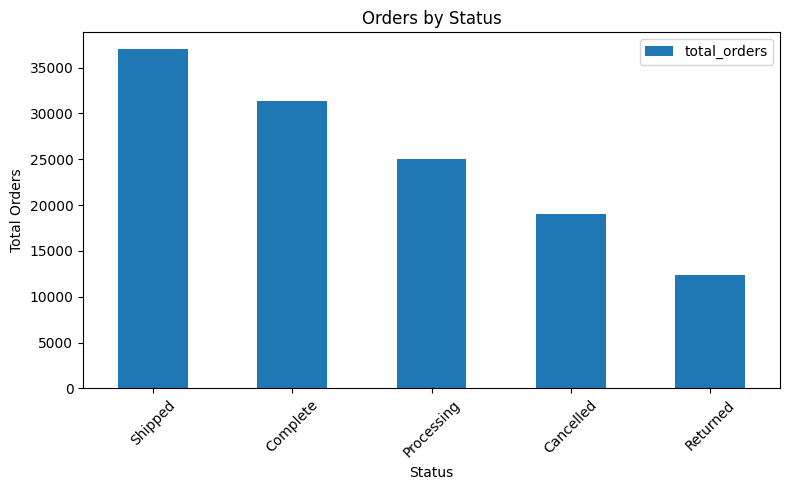

In [ ]:
import matplotlib.pyplot as plt

status_summary.plot(
    x="status",
    y="total_orders",
    kind="bar",
    figsize=(8,5)
)

plt.title("Orders by Status")
plt.xlabel("Status")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
monthly_orders = (
    df.groupby("month")
      .size()
      .reset_index(name="total_orders")
)

monthly_orders

,month,total_orders
0,2019-01,9
1,2019-02,21
2,2019-03,29
3,2019-04,48
4,2019-05,55
...,...,...
88,2026-05,4272
89,2026-06,4338
90,2026-07,5241
91,2026-08,5897


In [ ]:
top_month = (
    monthly_orders
    .sort_values("total_orders", ascending=True)
    .head(10)
)

top_month

,month,total_orders
0,2019-01,9
1,2019-02,21
2,2019-03,29
3,2019-04,48
4,2019-05,55
5,2019-06,70
6,2019-07,93
7,2019-08,106
8,2019-09,123
10,2019-11,141


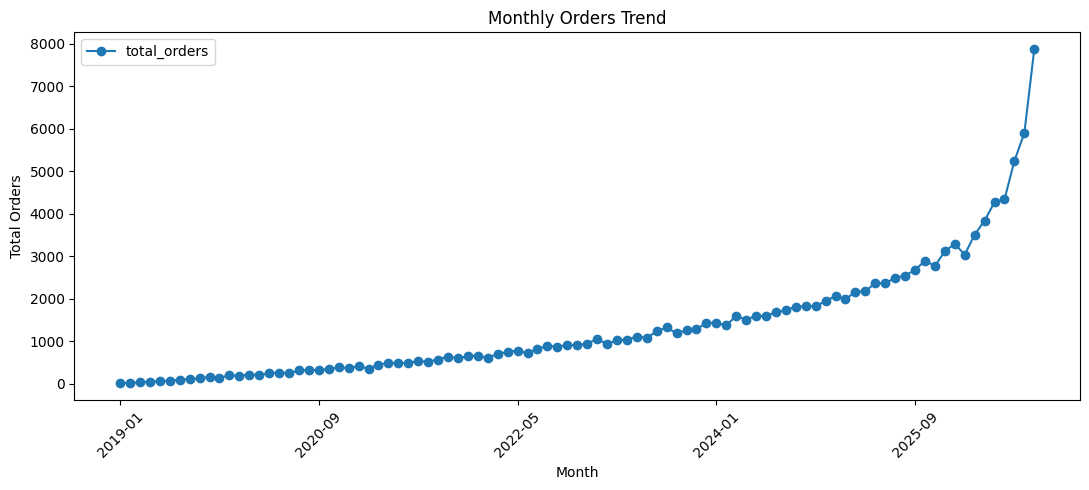

In [ ]:
monthly_orders.plot(
    x="month",
    y="total_orders",
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("Monthly Orders Trend")
plt.xlabel("Month")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
daily_orders = (
    df.groupby("order_date")
      .size()
      .reset_index(name="total_orders")
)

daily_orders.head()

,order_date,total_orders
0,2019-01-09,1
1,2019-01-13,1
2,2019-01-15,2
3,2019-01-25,1
4,2019-01-26,1


In [ ]:
top_days = (
    daily_orders
    .sort_values("total_orders", ascending=False)
    .tail(100)
)

top_days

,order_date,total_orders
189,2019-09-13,2
179,2019-09-03,2
184,2019-09-08,2
180,2019-09-04,2
216,2019-10-10,2
...,...,...
41,2019-03-28,1
43,2019-04-01,1
42,2019-03-30,1
29,2019-03-15,1


In [ ]:
daily_orders[daily_orders["total_orders"] < 2]

,order_date,total_orders
0,2019-01-09,1
1,2019-01-13,1
3,2019-01-25,1
4,2019-01-26,1
5,2019-01-27,1
...,...,...
240,2019-11-03,1
247,2019-11-10,1
345,2020-02-16,1
428,2020-05-09,1


In [ ]:
complete_df = df[
    df["status"] == "Complete"
].copy()

print("Complete Orders:", len(complete_df))

Complete Orders: 31351


In [ ]:
total_orders = len(df)
complete_orders = len(complete_df)

complete_rate = round(
    complete_orders / total_orders * 100,
    2
)

print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")

Total Orders   : 124873
Complete Orders: 31351
Complete Rate  : 25.11 %


In [ ]:
complete_df["month"] = (
    complete_df["created_at"]
    .dt.to_period("M")
    .astype(str)
)

complete_monthly = (
    complete_df
    .groupby("month")
    .size()
    .reset_index(name="complete_orders")
)

complete_monthly

/tmp/ipykernel_988/2665706029.py:3: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .dt.to_period("M")


,month,complete_orders
0,2019-02,7
1,2019-03,12
2,2019-04,15
3,2019-05,16
4,2019-06,9
...,...,...
87,2026-05,1053
88,2026-06,1085
89,2026-07,1267
90,2026-08,1526


In [ ]:
top_monthly_complete = (
    complete_monthly
    .sort_values("complete_orders", ascending=False)
    .head(10)
)

top_monthly_complete

,month,complete_orders
91,2026-09,1985
90,2026-08,1526
89,2026-07,1267
88,2026-06,1085
87,2026-05,1053
86,2026-04,958
85,2026-03,881
83,2026-01,844
82,2025-12,799
84,2026-02,777


In [ ]:
comparison = monthly_orders.merge(
    complete_monthly,
    on="month",
    how="left"
).fillna(0)

comparison["complete_orders"] = (
    comparison["complete_orders"].astype(int)
)

comparison.head()

,month,total_orders,complete_orders
0,2019-01,9,0
1,2019-02,21,7
2,2019-03,29,12
3,2019-04,48,15
4,2019-05,55,16


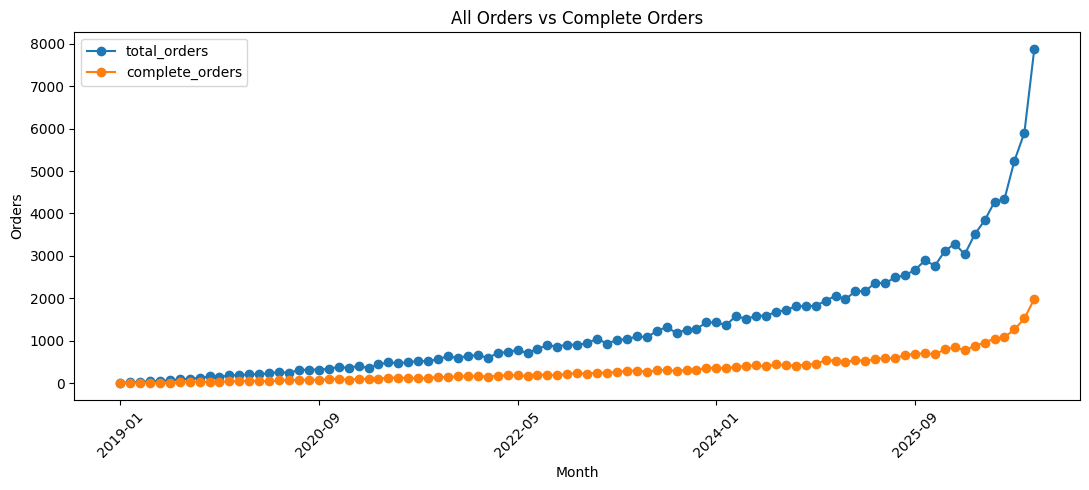

In [ ]:
comparison.plot(
    x="month",
    y=["total_orders", "complete_orders"],
    kind="line",
    marker="o",
    figsize=(11,5)
)

plt.title("All Orders vs Complete Orders")
plt.xlabel("Month")
plt.ylabel("Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
query_users = '''
SELECT
  id AS user_id,
  first_name,
  last_name,
  gender,
  age,
  country
FROM `bigquery-public-data.thelook_ecommerce.users`
'''

users = client.query(query_users).to_dataframe()

users.head()

,user_id,first_name,last_name,gender,age,country
0,2049,Michelle,Lopez,F,12,Japan
1,11303,Adam,Watkins,M,12,Japan
2,12703,Brian,Mills,M,12,United States
3,80178,Nicole,Coleman,F,12,United States
4,78600,Robert,Williams,M,12,Brasil


In [ ]:
country_summary = (
    users["country"]
      .value_counts()
      .reset_index()
)
country_summary.columns = ["country", "total_users"]

country_summary

,country,total_users
0,China,33890
1,United States,22245
2,Brasil,14683
3,South Korea,5370
4,France,4814
5,United Kingdom,4684
6,Germany,4130
7,Spain,4079
8,Japan,2420
9,Australia,2201


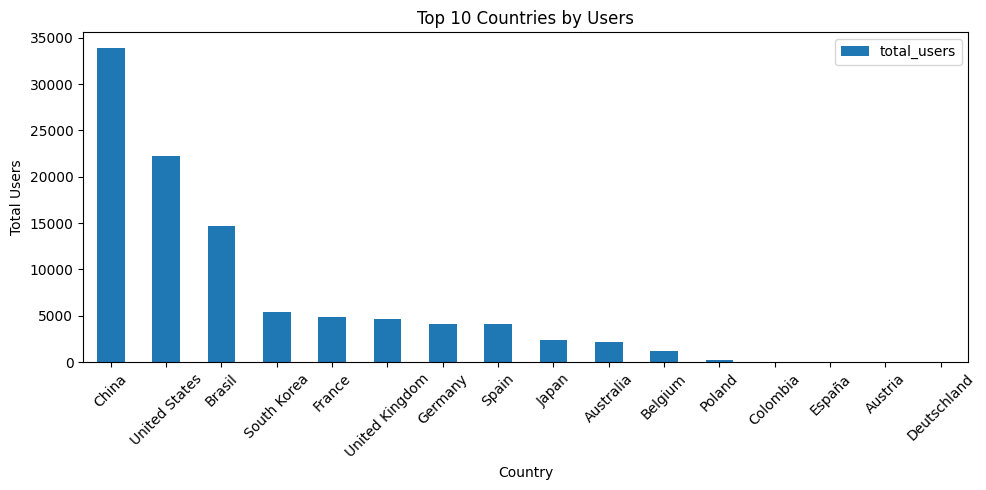

In [ ]:
country_summary.plot(
    x="country",
    y="total_users",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Users")
plt.xlabel("Country")
plt.ylabel("Total Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
gender_summary = (
    users["gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = [
    "gender",
    "total_users"
]

gender_summary

,gender,total_users
0,F,50202
1,M,49798


In [ ]:
average_age = round(
    users["age"].mean(),
    2
)

print("Average Age:", average_age)

Average Age: 40.92


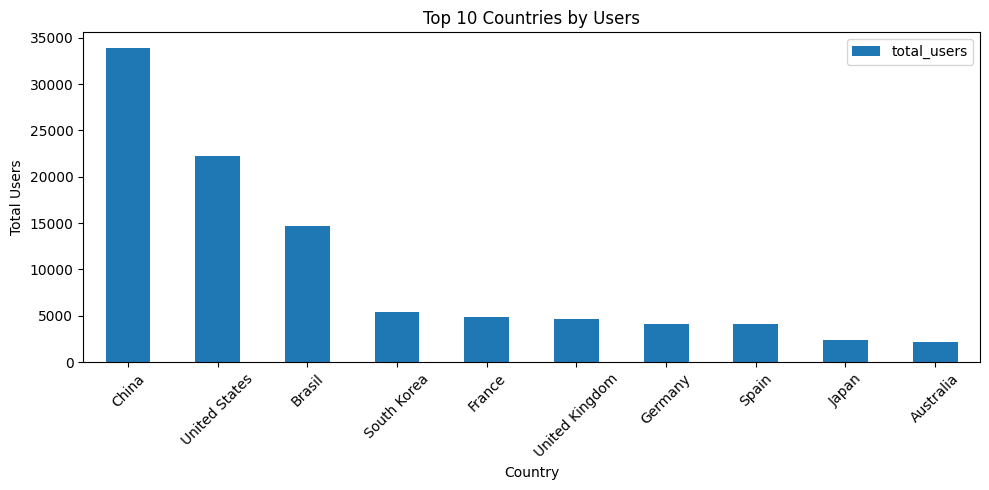

,gender,total_users
0,F,50202
1,M,49798


In [ ]:
country_summary.head(10).plot(
    x="country",
    y="total_users",
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries by Users")
plt.xlabel("Country")
plt.ylabel("Total Users")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
gender_summary = (
    users["gender"]
    .value_counts()
    .reset_index()
)

gender_summary.columns = [
    "gender",
    "total_users"
]

gender_summary

In [ ]:
kpi = pd.DataFrame({
    "metric": [
        "Total Orders",
        "Complete Orders",
        "Complete Rate",
        "Average User Age"
    ],
    "value": [
        total_orders,
        complete_orders,
        complete_rate,
        average_age
    ]
})

kpi

,metric,value
0,Total Orders,124873.00
1,Complete Orders,31351.00
2,Complete Rate,25.11
3,Average User Age,40.92


In [ ]:
average_age = round(
    users["age"].mean(),
    2
)

print("Average Age:", average_age)
top_country = country_summary.head(10)
print("===== KEY METRICS =====")
print("Total Orders   :", total_orders)
print("Complete Orders:", complete_orders)
print("Complete Rate  :", complete_rate, "%")
print("Average Age    :", average_age)

print("\nTop Month:")
display(top_month)

print("\nTop 10 Countries:")
display(top_country)

print("\nStatus Summary:")
display(status_summary)

Average Age: 40.92
===== KEY METRICS =====
Total Orders   : 124873
Complete Orders: 31351
Complete Rate  : 25.11 %
Average Age    : 40.92

Top Month:


,month,total_orders
0,2019-01,9
1,2019-02,21
2,2019-03,29
3,2019-04,48
4,2019-05,55
5,2019-06,70
6,2019-07,93
7,2019-08,106
8,2019-09,123
10,2019-11,141



Top 10 Countries:


,country,total_users
0,China,33890
1,United States,22245
2,Brasil,14683
3,South Korea,5370
4,France,4814
5,United Kingdom,4684
6,Germany,4130
7,Spain,4079
8,Japan,2420
9,Australia,2201



Status Summary:


,status,total_orders,percentage
0,Shipped,36993,29.62
1,Complete,31351,25.11
2,Processing,25073,20.08
3,Cancelled,19069,15.27
4,Returned,12387,9.92


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'session8_top_country.csv', 'session8_country_summary.csv', 'session8_complete_monthly.csv', 'session8_kpi.csv', 'session8_gender_summary.csv', 'session8_monthly_orders.csv', 'session8_comparison.csv', 'session8_status_summary.csv', 'session8_daily_orders.csv', 'sample_data']


In [ ]:
%whos

Variable               Type         Data/Info
---------------------------------------------
PROJECT_ID             str          lenas-projects
auth                   module       <module 'google.colab.aut<...>es/google/colab/auth.py'>
average_age            float64      40.92
bigquery               module       <module 'google.cloud.big<...>ud/bigquery/__init__.py'>
client                 Client       <google.cloud.bigquery.cl<...>object at 0x7c5f30459f90>
comparison             DataFrame          month  total_orders<...>\n\n[93 rows x 3 columns]
complete_df            DataFrame           order_id  user_id <...>n[31351 rows x 6 columns]
complete_monthly       DataFrame          month  complete_ord<...>\n\n[92 rows x 2 columns]
complete_orders        int          31351
complete_rate          float        25.11
country_summary        DataFrame               country  total<...> Deutschland            1
daily_orders           DataFrame          order_date  total_o<...>\n[2753 rows x 2 colu

In [ ]:
top_country.to_csv("/content/session8_top_country.csv", index=False)
kpi.to_csv("/content/session8_kpi.csv", index=False)
complete_monthly.to_csv("/content/session8_complete_monthly.csv", index=False)
comparison.to_csv("/content/session8_comparison.csv", index=False)
daily_orders.to_csv("/content/session8_daily_orders.csv", index=False)
monthly_orders.to_csv("/content/session8_monthly_orders.csv", index=False)
status_summary.to_csv("/content/session8_status_summary.csv", index=False)
gender_summary.to_csv("/content/session8_gender_summary.csv", index=False)
country_summary.to_csv("/content/session8_country_summary.csv", index=False)

print("Semua file berhasil disimpan!")

Semua file berhasil disimpan!
